In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings 
warnings.filterwarnings('ignore')

#  Data Loading & Exploration
Do the following: 1. Load the Titanic dataset using seaborn 2. Display the first 10 rows. 3.
Count missing values in each column 4. Display column names. 5. Show unique values in the
embarked column.

In [5]:
#1
df_titanic = sns.load_dataset('titanic')
#2 
df_titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [6]:
#3 
df_titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
#4 
df_titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
#5
df_titanic['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

# Data Cleaning
Do the following: 1. Fill missing embarked with the most frequent value. 2. Convert sex and
class to categorical type. 3. Create a new column family_size= sibsp + parch + 1. 4. Cap
fare at the 99th percentile to reduce outlier impact.

In [9]:
#1
most_frequent = df_titanic['embarked'].mode()[0]
df_titanic['embarked'].fillna(most_frequent, inplace=True)

In [10]:
#2
tocategorical_col = ['sex', 'class']
for col in tocategorical_col:
    df_titanic[col] = df_titanic[col].astype('category')

In [11]:
#3
family_size = df_titanic['sibsp'] + df_titanic['parch'] + 1

In [12]:
#4 
upper_bound = df_titanic['fare'].quantile(0.99)
df_titanic['fare'] = df_titanic['fare'].clip(upper=upper_bound)

# Visualization
Do the following: 1. Pairplot of ['age', 'fare', 'sibsp'] colored by survived. 2. Heatmap
of correlations for numeric columns. 3. Scatter plot of age vs fare, colored by survived. 4. Plot
a histogram of age with 30 bins and KDE

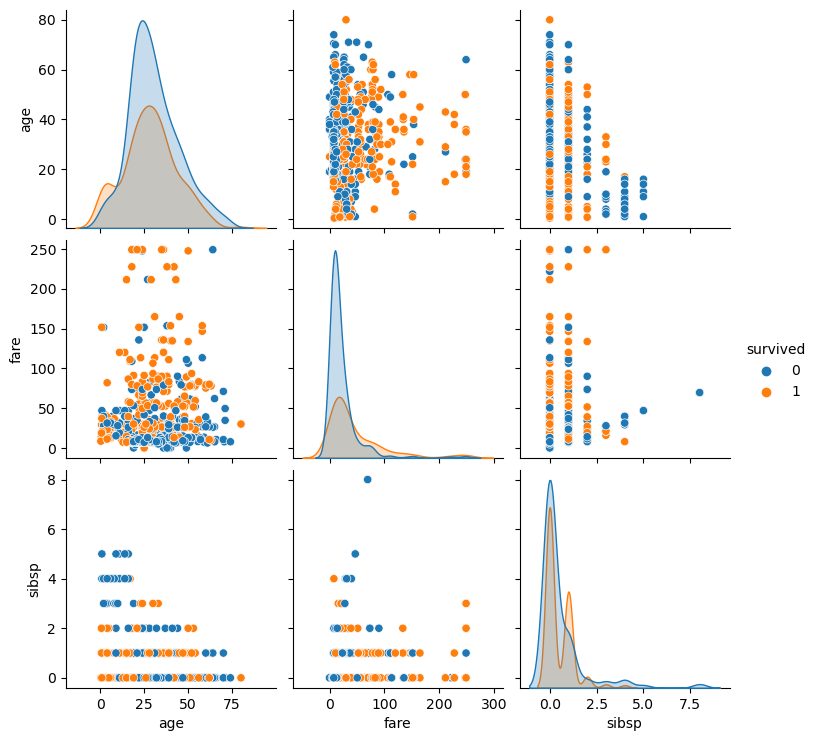

In [13]:
sns.pairplot(df_titanic, vars=['age', 'fare', 'sibsp'], hue='survived', diag_kind='kde')
plt.show()

In [14]:
df_titanic.select_dtypes(include='number')

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,NaN,1,2,23.4500
889,1,1,26.0,0,0,30.0000


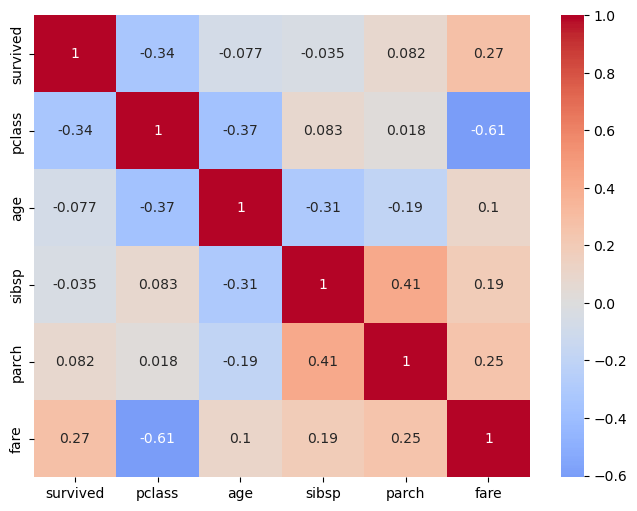

In [15]:
plt.figure(figsize=(8, 6))
numeric_col = df_titanic.select_dtypes(include=np.number).columns
sns.heatmap(df_titanic[numeric_col].corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

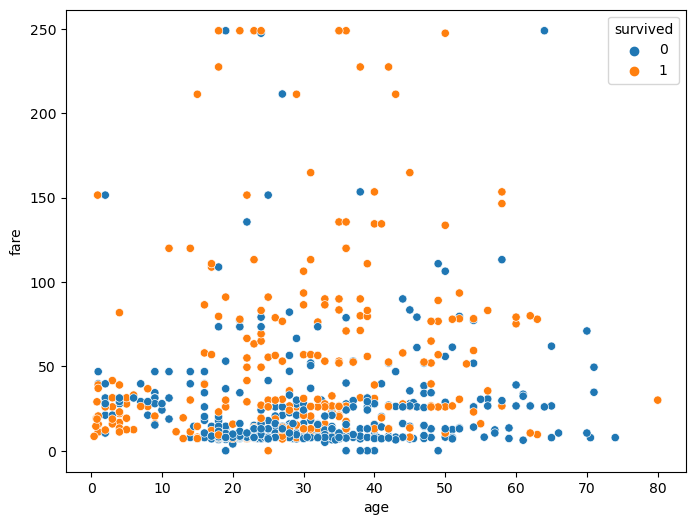

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_titanic, x='age', y='fare', hue='survived')
plt.show()

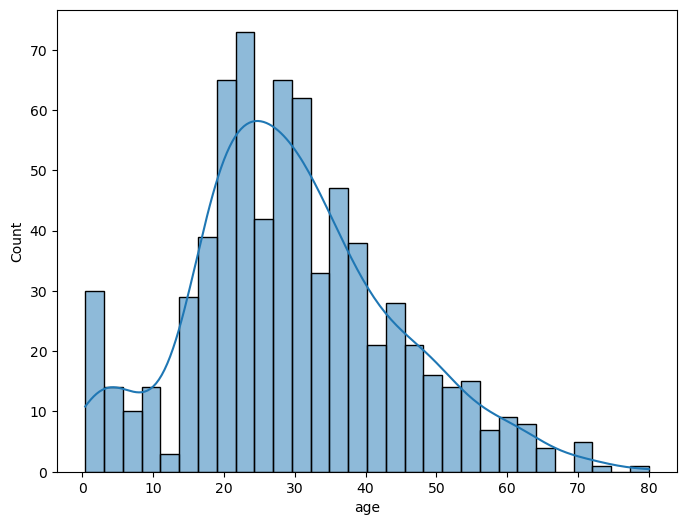

In [17]:
plt.figure(figsize=(8, 6))
sns.histplot(df_titanic['age'], bins=30, kde=True)
plt.show()